In [1]:
import os

print(os.path.abspath(os.curdir))

e:\Data Kuliah\S2 ITS\Semester 5\Sentiment Analysis\IEEE IFS\DroneLog\notebooks


In [2]:
import os
os.chdir("..")

In [3]:
print(os.path.abspath(os.curdir))

e:\Data Kuliah\S2 ITS\Semester 5\Sentiment Analysis\IEEE IFS\DroneLog


In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

def generate_chi_sq(dataset, encoder, dataframe):
    chi2_results = {}
    p_value = {}
    # Loop through each categorical column (excluding the evaluation score column)
    for column in dataframe.columns:
        if column != 'accuracy':
        # if column != evaluation_score and dataframe[column].dtype == 'object':
            # Create a contingency table
            contingency_table = pd.crosstab(dataframe[column], dataframe['accuracy'])
            
            # Perform the chi-squared test
            chi2, p_val, _, _ = chi2_contingency(contingency_table)
            
            # Store the chi-squared statistic in the dictionary
            chi2_results[column] = chi2
            p_value[column] = p_val

    # print(f"chi: {chi2_results}")
    # print(f"p_val: {p_value}")

    # Sort the results by chi-squared statistic in descending order
    sorted_chi2_results = dict(sorted(chi2_results.items(), key=lambda item: item[1], reverse=True))

    # Plot the chi-squared statistics
    plt.figure(figsize=(6, 4))
    sns.barplot(x=list(sorted_chi2_results.keys()), y=list(sorted_chi2_results.values()))
    plt.xticks(rotation=90)
    plt.xlabel('Categorical Columns')
    plt.ylabel('Chi-squared Statistic')
    plt.title(f'Chi-squared Test for {dataset}-{encoder} vs. Accuracy')
    # plt.savefig(os.path.join('visualizations/chi-square', f"{dataset}_{encoder}.pdf"), bbox_inches='tight')
    # plt.show()
    plt.close()
    return chi2_results, p_value

In [23]:
import collections
# Load your dataset into a pandas DataFrame
# Replace 'your_dataset.csv' with the actual file path
data = pd.read_excel('experiments/recap/final-recap-all.xlsx')
# data_filtered = data[data['dataset'] == 'fold5']
# data_unfiltered = data[data['dataset'] == 'unfiltered']
encoders = list(set(data['encoder'].to_list()))
datasets = list(set(data['dataset'].to_list()))
# Specify the evaluation score you want to analyze (e.g., 'accuracy' or 'f1_score')
evaluation_score = 'accuracy'
recap_chi = collections.defaultdict(dict)
# print(f'data: {len(data)}')
# Bisa diganti line plot buat dua garis aja untuk filtered and unfiltered dataset.
# Initialize an empty dictionary to store chi-squared test results
for dataset in datasets:
    data_dataset = data[data['dataset'] == dataset]
    # print(f'data_dataset: {len(data_dataset)}')
    for encoder in encoders:
        exclude_cols = ['recall', 'precision', 'f1_score', 'best_epoch', 'dataset']
        data_encoder = data_dataset[data_dataset['encoder'] == encoder]
        # print(f'data_encoder: {len(data_encoder)}')
        data_ready = data_encoder.drop(exclude_cols, axis=1)
        chi2_results, p_value = generate_chi_sq(dataset, encoder, data_ready)
        # print(f'dataset: {dataset}, encoder: {encoder}')
        # print(f'chi2_results: {chi2_results}, p_value: {p_value}')
        # print(f'data_ready: \n{data_ready}')
        joined_string = dataset + '_' + encoder
        # for key, value in chi2_results.items():
        #     recap_chi[joined_string][key]['chi'] = value
        # for key, value in p_value.items():
        #     recap_chi[joined_string][key]['p_value'] = value
        recap_chi[dataset][encoder] = {'chi': chi2_results, 'p_value': p_value}
# recap_chi

In [24]:
def nested_dict():
   return collections.defaultdict(nested_dict)
restructured_list = []
restructured = nested_dict()
for dataset, values in recap_chi.items():
    for encoder, chis in values.items():
        # print(f'chi: {chis.items()}')
        hyperparams = []
        chi_score = []
        p_score = []
        if encoder == 'none' or encoder == 'linear':
            encoder = 'Linear'
        elif len(encoder) < 5:
            encoder = str.upper(encoder)
        else:
            encoder = 'Trans'
        dataset_short = 'F' if dataset =='filtered' else 'U'
        dataset_encoder = dataset_short + '-' + encoder
        for chi, variables in chis.items():
            if chi == 'chi':
                for variable, value in variables.items():
                    if variable == 'encoder':
                        continue
                    hyperparams.append(variable)
                    chi_score.append(value)
                    # restructured[dataset_encoder][variable]['chi'] = value
            else:
                for variable, value in variables.items():
                    if variable == 'encoder':
                        continue
                    p_score.append(value)
                    # restructured[dataset_encoder][variable]['p_value'] = value
                    # print(f'dataset: {dataset}, encoder: {encoder}, chi: {chi}, variable: {variable}, value: {value}')
        for i in range(0, len(hyperparams)):
            restructured_list.append([dataset_encoder, hyperparams[i], chi_score[i], round(p_score[i], 2)])
print(restructured_list)

[['U-LSTM', 'n_layer', 25.893939393939394, 0.47], ['U-LSTM', 'n_head', 0.0, 1.0], ['U-LSTM', 'bidirectional', 14.773448773448772, 0.32], ['U-LSTM', 'pooling', 0.0, 1.0], ['U-LSTM', 'class_weight', 21.48701298701299, 0.72], ['U-LSTM', 'scenario', 51.67965367965368, 0.08], ['U-GRU', 'n_layer', 27.523976023976022, 0.12], ['U-GRU', 'n_head', 0.0, 1.0], ['U-GRU', 'bidirectional', 13.492507492507492, 0.2], ['U-GRU', 'pooling', 0.0, 1.0], ['U-GRU', 'class_weight', 33.10289710289711, 0.03], ['U-GRU', 'scenario', 33.897879897879896, 0.28], ['U-Linear', 'n_layer', 0.0, 1.0], ['U-Linear', 'n_head', 0.0, 1.0], ['U-Linear', 'bidirectional', 0.0, 1.0], ['U-Linear', 'pooling', 38.51774891774892, 0.14], ['U-Linear', 'class_weight', 24.105194805194806, 0.24], ['U-Linear', 'scenario', 35.22251082251083, 0.23], ['U-Trans', 'n_layer', 53.15291331737528, 0.01], ['U-Trans', 'n_head', 33.022044830845026, 0.32], ['U-Trans', 'bidirectional', 0.0, 1.0], ['U-Trans', 'pooling', 49.33357142865524, 0.3], ['U-Trans'

In [25]:
def transform_cols(column):
    if column == 'n_layer':
        return 'Num. Layer'
    elif column == 'n_head':
        return 'Num. Head'
    elif column == 'bidirectional':
        return 'Bidirectional'
    elif column == 'pooling':
        return 'Pooling'
    elif column == 'scenario':
        return 'Scenario'
    elif column == 'class_weight':
        return 'Class Weight'

In [26]:
import pandas as pd

akhirnya_df = pd.DataFrame(restructured_list, columns=['Dataset-Encoder', 'Hyperparameter', 'chi-score', 'p-value'])
akhirnya_df['Hyperparameter'] = akhirnya_df['Hyperparameter'].apply(transform_cols)
akhirnya_df

,Dataset-Encoder,Hyperparameter,chi-score,p-value
0,U-LSTM,Num. Layer,25.893939,0.47
1,U-LSTM,Num. Head,0.000000,1.00
2,U-LSTM,Bidirectional,14.773449,0.32
3,U-LSTM,Pooling,0.000000,1.00
4,U-LSTM,Class Weight,21.487013,0.72
5,U-LSTM,Scenario,51.679654,0.08
6,U-GRU,Num. Layer,27.523976,0.12
7,U-GRU,Num. Head,0.000000,1.00
8,U-GRU,Bidirectional,13.492507,0.20
9,U-GRU,Pooling,0.000000,1.00


   Dataset-Encoder Hyperparameter  chi-score  p-value
0           U-LSTM     Num. Layer  25.893939     0.47
1           U-LSTM      Num. Head   0.000000     1.00
2           U-LSTM  Bidirectional  14.773449     0.32
3           U-LSTM        Pooling   0.000000     1.00
4           U-LSTM   Class Weight  21.487013     0.72
5           U-LSTM       Scenario  51.679654     0.08
6            U-GRU     Num. Layer  27.523976     0.12
7            U-GRU      Num. Head   0.000000     1.00
8            U-GRU  Bidirectional  13.492507     0.20
9            U-GRU        Pooling   0.000000     1.00
10           U-GRU   Class Weight  33.102897     0.03
11           U-GRU       Scenario  33.897880     0.28
12        U-Linear     Num. Layer   0.000000     1.00
13        U-Linear      Num. Head   0.000000     1.00
14        U-Linear  Bidirectional   0.000000     1.00
15        U-Linear        Pooling  38.517749     0.14
16        U-Linear   Class Weight  24.105195     0.24
17        U-Linear       Sce

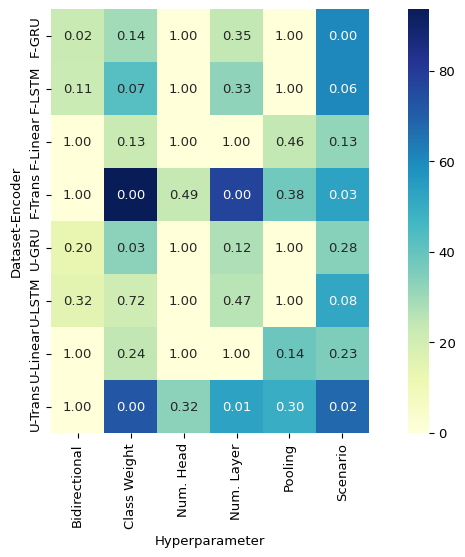

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
# matplotlib.rcParams['font.family'] = 'Times New Roman'
matplotlib.rcParams['font.size'] = 9.5
# Sample data
# data = {
#     'encoder': ['enc1', 'enc1', 'enc2', 'enc2', 'enc3', 'enc3', 'enc4', 'enc4', 'enc5', 'enc5', 'enc6', 'enc6', 'enc7', 'enc7', 'enc8', 'enc8'],
#     'hyperparam': ['var1', 'var2', 'var1', 'var2', 'var1', 'var2', 'var1', 'var2', 'var1', 'var2', 'var1', 'var2', 'var1', 'var2', 'var1', 'var2'],
#     'chi-score': [10.5, 15.2, 8.9, 12.8, 9.4, 14.6, 11.7, 16.3, 7.8, 13.5, 10.1, 15.8, 9.9, 14.0, 12.3, 17.1],
#     'p-value': [0.001, 0.0001, 0.002, 0.0002, 0.0015, 0.00005, 0.0012, 0.00009, 0.0023, 0.00008, 0.0011, 0.00012, 0.0014, 0.00007, 0.00015, 0.00004]
# }
# data = {
#     'encoder': akhirnya_df['encoder'].to_list(),
#     'hyperparam': akhirnya_df['hyperparam'].to_list(),
#     'chi-score': akhirnya_df['chi-score'].to_list(),
#     'p-value': akhirnya_df['p-value'].to_list()
# }

df = akhirnya_df
# df = pd.DataFrame(data)
print(df)
# Pivot the DataFrame to create a matrix
# heatmap_data = df.pivot("encoder", "variables", "chi-score")
heatmap_data = df.pivot(index='Dataset-Encoder', columns='Hyperparameter', values='chi-score')


# Create a heatmap with p-values as labels
plt.figure(figsize=(10, 5.5))
ax = sns.heatmap(heatmap_data, annot=df.pivot(index="Dataset-Encoder", columns="Hyperparameter", values="p-value"), cmap="YlGnBu", fmt=".2f", cbar=True, square=True)
# plt.title("Chi-Square Test Results by Variable and Encoder")
plt.savefig(os.path.join('visualizations', "categorical_hyperparams-time.pdf"), bbox_inches='tight')
plt.show()
plt.close()
